# Анализ успешности патча

Структурированный ноутбук для кеширования clean/patched атаки, анализа распространения патча и SegmentIG-only метрик success/fail. Тяжелая логика вынесена в `new_experiments/patch_success_analysis/`.

## Настройка и кеш атаки

Кеш строится так: запускаем атаку на пуле изображений из датасета, считаем `drop = conf_clean - conf_patch`, размечаем `success = drop > success_thresh` и сохраняем сбалансированную выборку success/fail.

In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import pandas as pd
from IPython.display import Image, display

from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    make_coco_people_patch_success_experiment,
    select_balanced_rows,
)

source_pool_size = 7200
source_n_success = 3000
source_n_fail = 3000
analysis_examples_per_class = 3000
force_success_failure_metrics_recompute = False

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment(
    pool_size=source_pool_size,
    n_success=source_n_success,
    n_fail=source_n_fail,
)
cache = exp.build_or_load_cache(force=False)
selected_per_class = min(analysis_examples_per_class, len(cache.successes), len(cache.failures))
selected_examples = cache.successes[:selected_per_class] + cache.failures[:selected_per_class]

print(f"cwd={cwd}")
print(f"device={attack_config.device}")
print(f"source attack cache key={attack_config.cache_key()}")
print(f"source attack cache path={attack_config.cache_path}")
print(
    f"selected={len(selected_examples)} "
    f"({sum(e.success for e in selected_examples)} success / {sum(not e.success for e in selected_examples)} fail)"
)
cache.to_summary()

cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
device=mps
source attack cache key=e91cdfc4a2c4e20d
source attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
selected=5300 (2650 success / 2650 fail)


{'cache_key': 'e91cdfc4a2c4e20d',
 'config': {'dataset_path': ['../datasets/COCO_people'],
  'patch_path': '../data/patch.png',
  'model_path': 'yolo11s.pt',
  'output_dir': 'new_experiments/outputs/patch_success_analysis',
  'imgsz': 640,
  'device': 'mps',
  'target_class_name': 'person',
  'conf': 0.01,
  'success_thresh': 0.3,
  'seed': 17,
  'pool_size': 7200,
  'n_success': 3000,
  'n_fail': 3000,
  'apply_patch_after_letterbox': True,
  'patch_xy': (0, 0)},
 'balanced_total': 5650,
 'balanced_success': 3000,
 'balanced_fail': 2650,
 'pool_total': 7200,
 'pool_success': 4550,
 'pool_fail': 2650,
 'pool_failed_images': 0,
 'failed_paths': []}

conf_clean                     conf_patch                      drop  \
             count      mean       std      count      mean       std count   
success                                                                       
False         2650  0.821928  0.217207       2650  0.704883  0.198854  2650   
True          3000  0.880509  0.060260       3000  0.169871  0.198685  3000   

                             
             mean       std  
success                      
False    0.117046  0.117150  
True     0.710638  0.199891

,path,conf_clean,conf_patch,drop,success,patch_bbox_lb,target_class_id,clean_detection
0,../datasets/COCO_people/06356_train2017_image4...,0.933572,0.531450,0.402123,True,"(0.0, 0.0, 160.0, 160.0)",0,"{'class_id': 0, 'class_name': 'person', 'confi..."
1,../datasets/COCO_people/00972_train2017_image3...,0.876672,0.240576,0.636096,True,"(0.0, 0.0, 160.0, 160.0)",0,"{'class_id': 0, 'class_name': 'person', 'confi..."
2,../datasets/COCO_people/01552_train2017_image1...,0.876263,0.000000,0.876263,True,"(0.0, 0.0, 160.0, 160.0)",0,"{'class_id': 0, 'class_name': 'person', 'confi..."
3,../datasets/COCO_people/02665_train2017_image8...,0.926853,0.557409,0.369444,True,"(0.0, 0.0, 160.0, 160.0)",0,"{'class_id': 0, 'class_name': 'person', 'confi..."
4,../datasets/COCO_people/04480_train2017_image1...,0.900169,0.895448,0.004722,False,"(0.0, 0.0, 160.0, 160.0)",0,"{'class_id': 0, 'class_name': 'person', 'confi..."


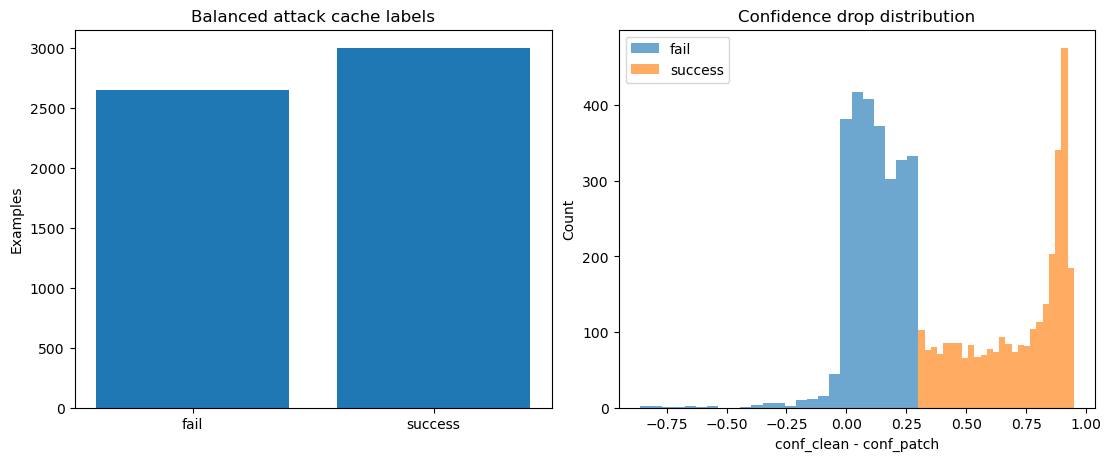

In [2]:
from patch_success_analysis.plots import plot_attack_cache_summary

cache_df = pd.DataFrame([item.to_dict() for item in cache.examples])
display(cache_df.groupby('success')[['conf_clean', 'conf_patch', 'drop']].agg(['count', 'mean', 'std']))
fig = plot_attack_cache_summary(cache_df)
cache_df.head()

## SegmentIG-only cached analysis

GeneralExperiments теперь использует общий COCO_people attack cache и SegmentIG-only derived cache. Success/fail метрики берутся из актуального `run_segmentig_success_failure_metrics()` cache.

In [3]:
# Attribution comparison block removed intentionally.
# This notebook now relies on SegmentIG-only cached metrics shared with BinMetrics/PatchSpread.
print("Attribution comparison block is disabled in this notebook.")
print("Use SegmentIG-only cache via run_segmentig_success_failure_metrics(force=False).")

Attribution comparison block is disabled in this notebook.
Use SegmentIG-only cache via run_segmentig_success_failure_metrics(force=False).


## Распространение патча по слоям

Legacy all-layer propagation оставлен выключенным: он не нужен для SegmentIG-only success/fail cache и может заново гонять тяжелые вычисления. Актуальные patch-spread эксперименты перенесены в `PatchSpread.ipynb`.

In [4]:
run_heavy_legacy_spread_blocks = False

if run_heavy_legacy_spread_blocks:
    spread_table = exp.run_all_layer_patch_spread_table(max_per_class=1)
    display(pd.DataFrame(spread_table['rows']))
    display(Image(filename=spread_table['figure_path']))

    examples = cache.successes[:2] + cache.failures[:2]
    propagation_rows = exp.run_patch_propagation(examples=examples, max_examples=4)
    display(pd.DataFrame(propagation_rows))
    for path in sorted((Path(config.attack.output_dir) / 'figures').glob('patch_propagation_*.png'))[:4]:
        display(Image(filename=str(path)))
else:
    print("Skipped legacy all-layer spread blocks. Use PatchSpread.ipynb for current cached spread experiments.")

Skipped legacy all-layer spread blocks. Use PatchSpread.ipynb for current cached spread experiments.


## Метрики success/fail

Delta-only метрики расползания и метрики согласования с `SegmentIG[0;0.1]` оцениваются как признаки для разделения успешных и неуспешных атак. Используется новый SegmentIG-only cache.

segmentig success/failure cache: new_experiments/outputs/patch_success_analysis/cache/segmentig_success_failure_metrics_3362be6645634ce2.pkl
loaded_from_cache=True
rows=5646, skipped=4
balanced rows=5292 (2646 success / 2646 fail)


,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path
61,segmentig_hand_rank_ratio_top5_top25,0.669002,0.640985,0.228035,1,new_experiments/outputs/patch_success_analysis...
55,segmentig_hand_rank_top5_delta_frac,0.667376,0.639391,0.056406,1,new_experiments/outputs/patch_success_analysis...
72,segmentig_hand_overlap_top5_delta_in_topA,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...
7,segmentig_delta_energy_in_importance_top,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...
5,segmentig_align_top_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...
71,segmentig_hand_overlap_top5_jaccard,0.667112,0.637797,0.039356,1,new_experiments/outputs/patch_success_analysis...
56,segmentig_hand_rank_top6_delta_frac,0.666895,0.637442,0.064968,1,new_experiments/outputs/patch_success_analysis...
19,segmentig_delta_energy_importance_bins_top10_l...,0.666285,0.637088,0.058602,1,new_experiments/outputs/patch_success_analysis...
21,segmentig_delta_energy_importance_bins_top10_exp,0.664821,0.635671,0.038404,1,new_experiments/outputs/patch_success_analysis...
68,segmentig_hand_overlap_top3_jaccard,0.663783,0.635494,0.029965,1,new_experiments/outputs/patch_success_analysis...


,path,success,conf_clean,conf_patch,drop,layer_maps_cache_path,layer_maps_loaded_from_cache,delta_l2_rms,delta_abs_mean,delta_max,...,segmentig_delta_energy_importance_binfrac_091,segmentig_delta_energy_importance_binfrac_092,segmentig_delta_energy_importance_binfrac_093,segmentig_delta_energy_importance_binfrac_094,segmentig_delta_energy_importance_binfrac_095,segmentig_delta_energy_importance_binfrac_096,segmentig_delta_energy_importance_binfrac_097,segmentig_delta_energy_importance_binfrac_098,segmentig_delta_energy_importance_binfrac_099,segmentig_delta_energy_importance_binfrac_100
0,../datasets/COCO_people/06356_train2017_image4...,True,0.933572,0.531450,0.402123,new_experiments/outputs/patch_success_analysis...,True,0.418452,0.379151,1.536133,...,0.009568,0.008953,0.010206,0.008397,0.009047,0.011265,0.013543,0.009482,0.009504,0.012763
1,../datasets/COCO_people/00972_train2017_image3...,True,0.876672,0.240576,0.636096,new_experiments/outputs/patch_success_analysis...,True,0.424955,0.401776,1.476562,...,0.009149,0.009241,0.009349,0.006625,0.009762,0.008928,0.012606,0.007821,0.008512,0.012693
2,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,0.000000,0.876263,new_experiments/outputs/patch_success_analysis...,True,0.553891,0.521082,1.422852,...,0.008660,0.009285,0.009119,0.009173,0.007501,0.011303,0.012669,0.011656,0.010060,0.012109
3,../datasets/COCO_people/02665_train2017_image8...,True,0.926853,0.557409,0.369444,new_experiments/outputs/patch_success_analysis...,True,0.417321,0.378869,1.523438,...,0.009544,0.009268,0.008853,0.007415,0.009159,0.008119,0.012072,0.008288,0.008849,0.013544
4,../datasets/COCO_people/02406_train2017_image2...,True,0.937165,0.000000,0.937165,new_experiments/outputs/patch_success_analysis...,True,0.406989,0.384673,1.526367,...,0.009968,0.009857,0.010576,0.008978,0.010511,0.010210,0.013505,0.009269,0.009404,0.011744


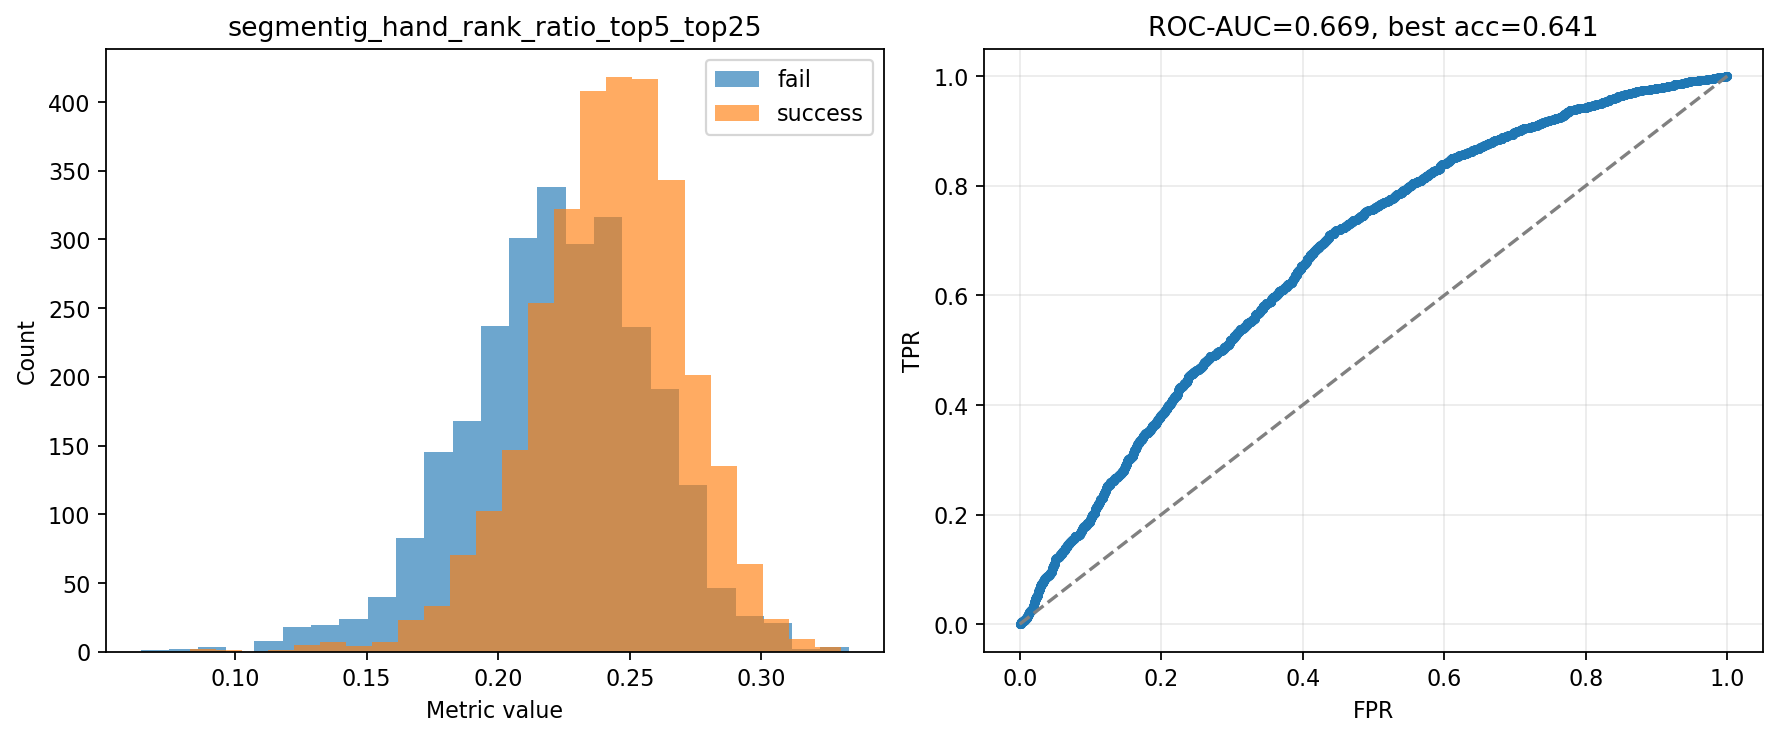

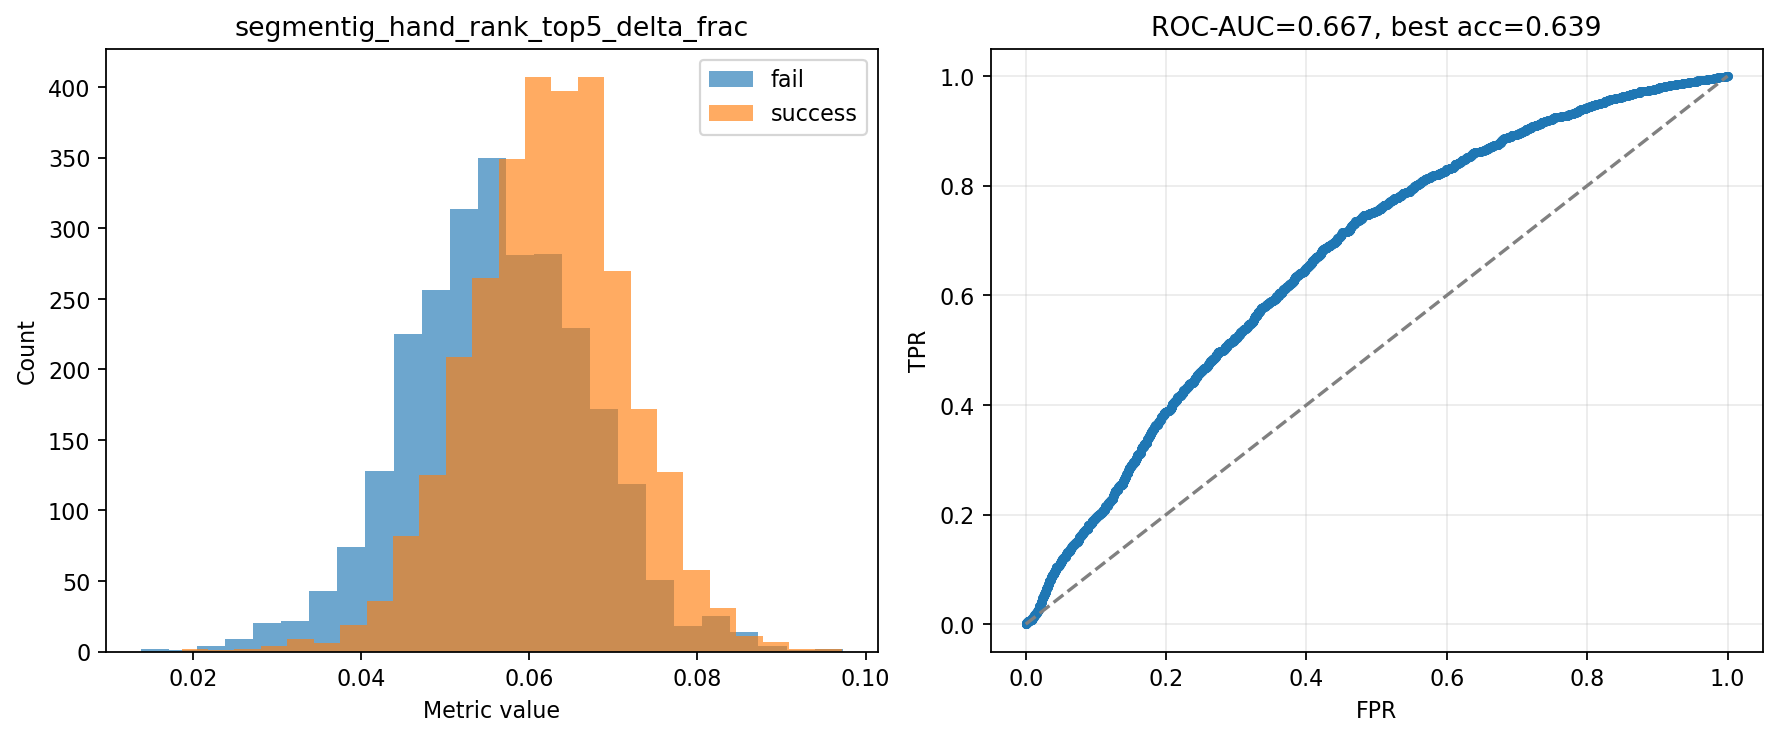

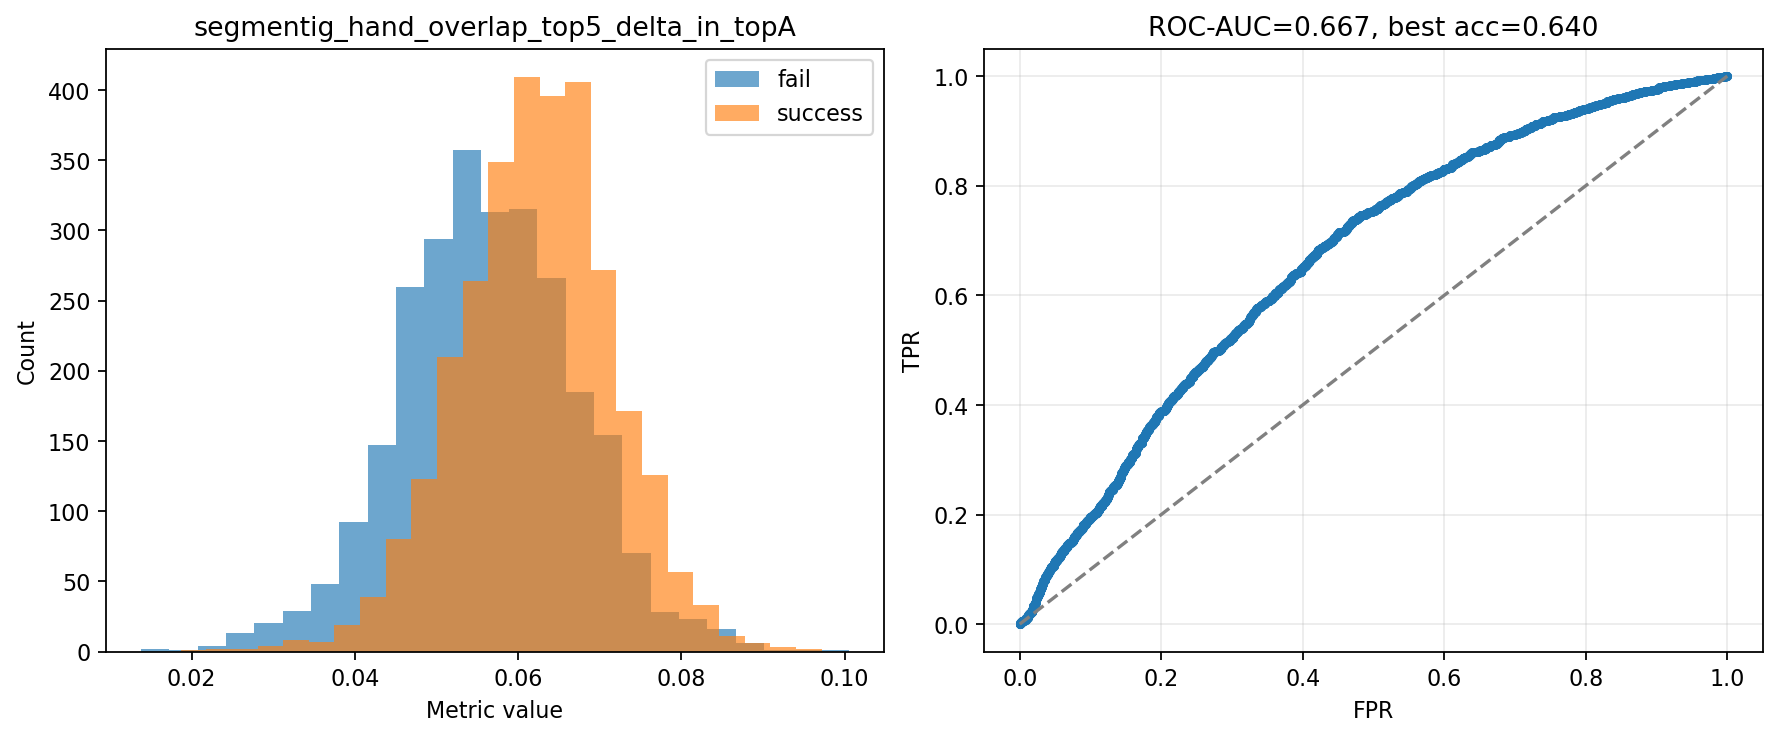

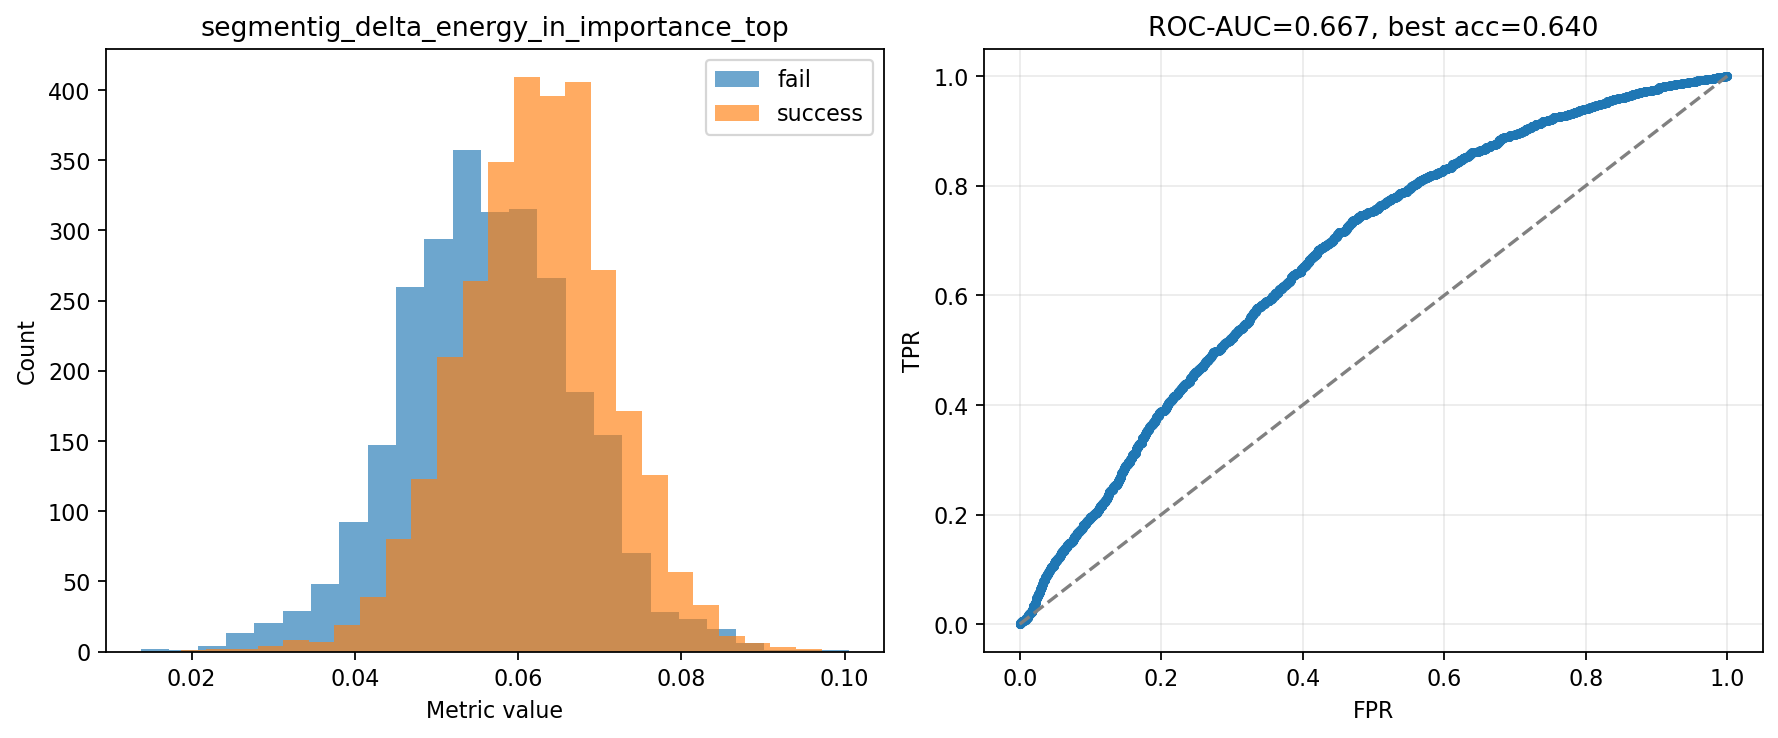

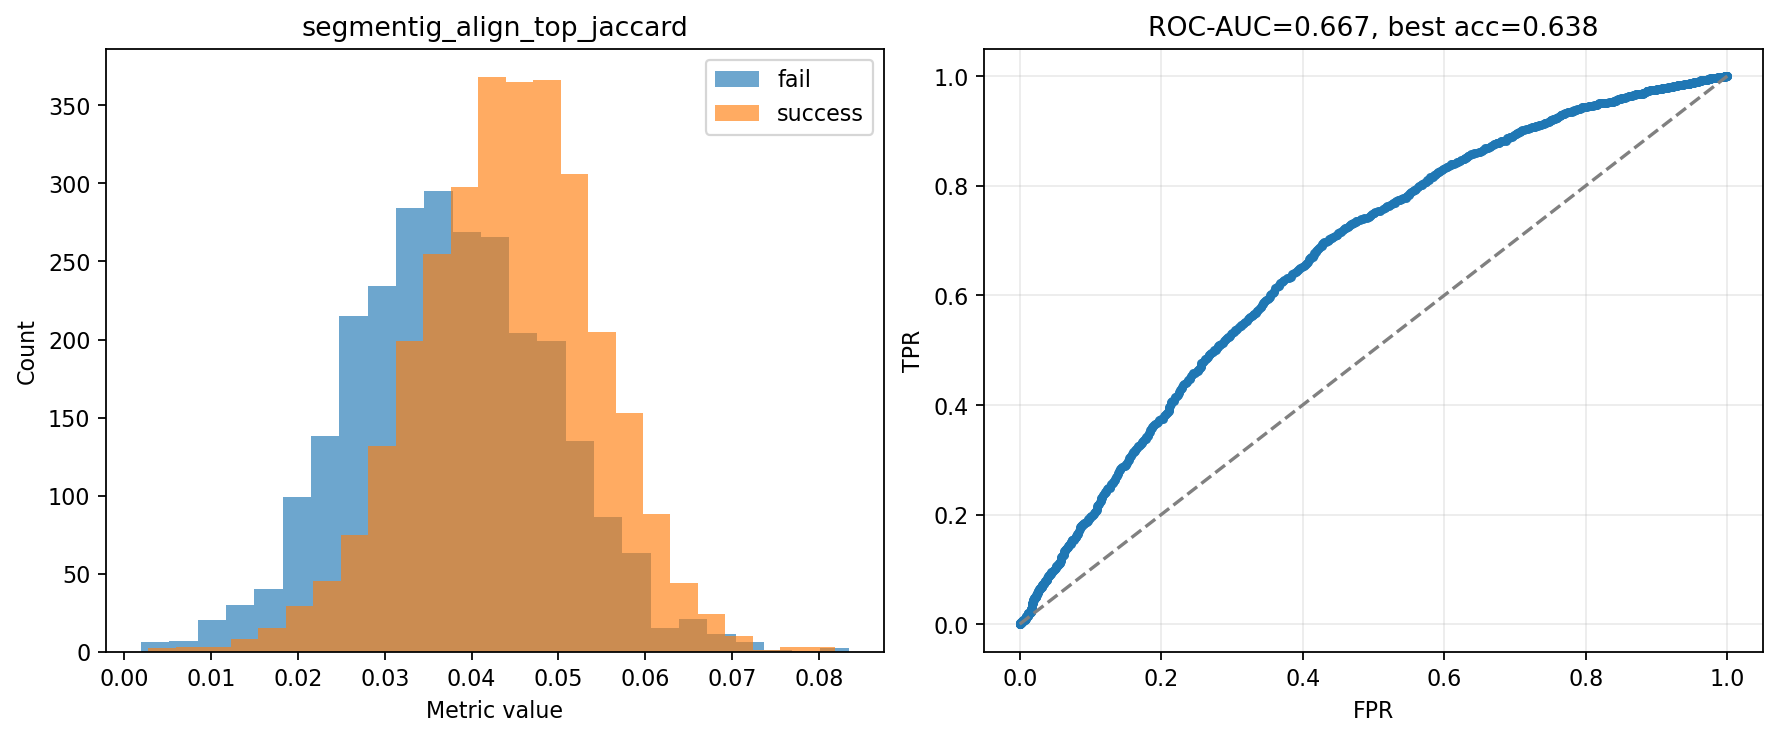

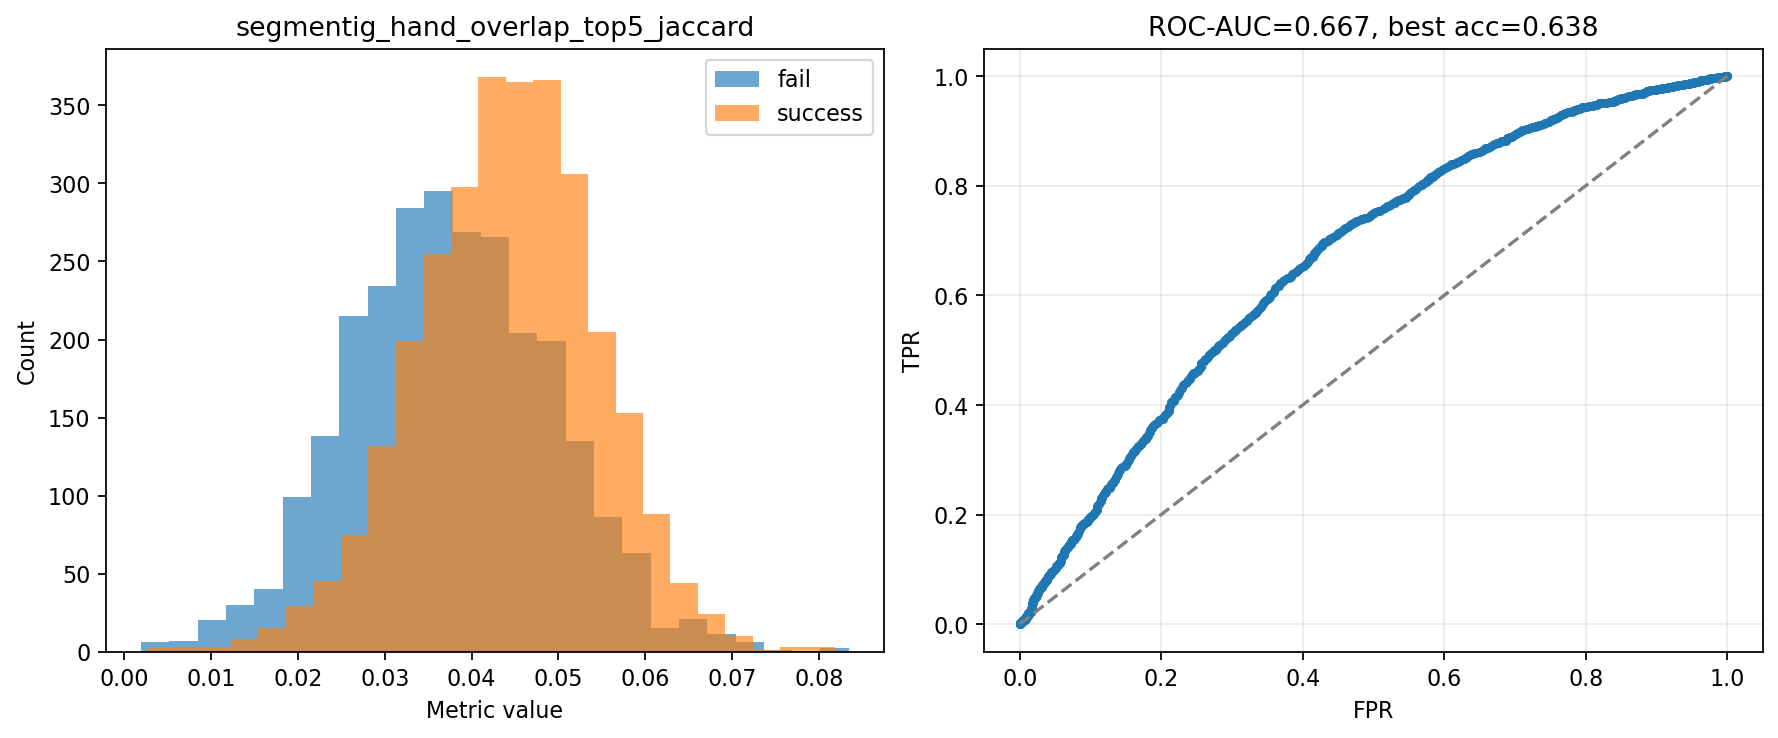

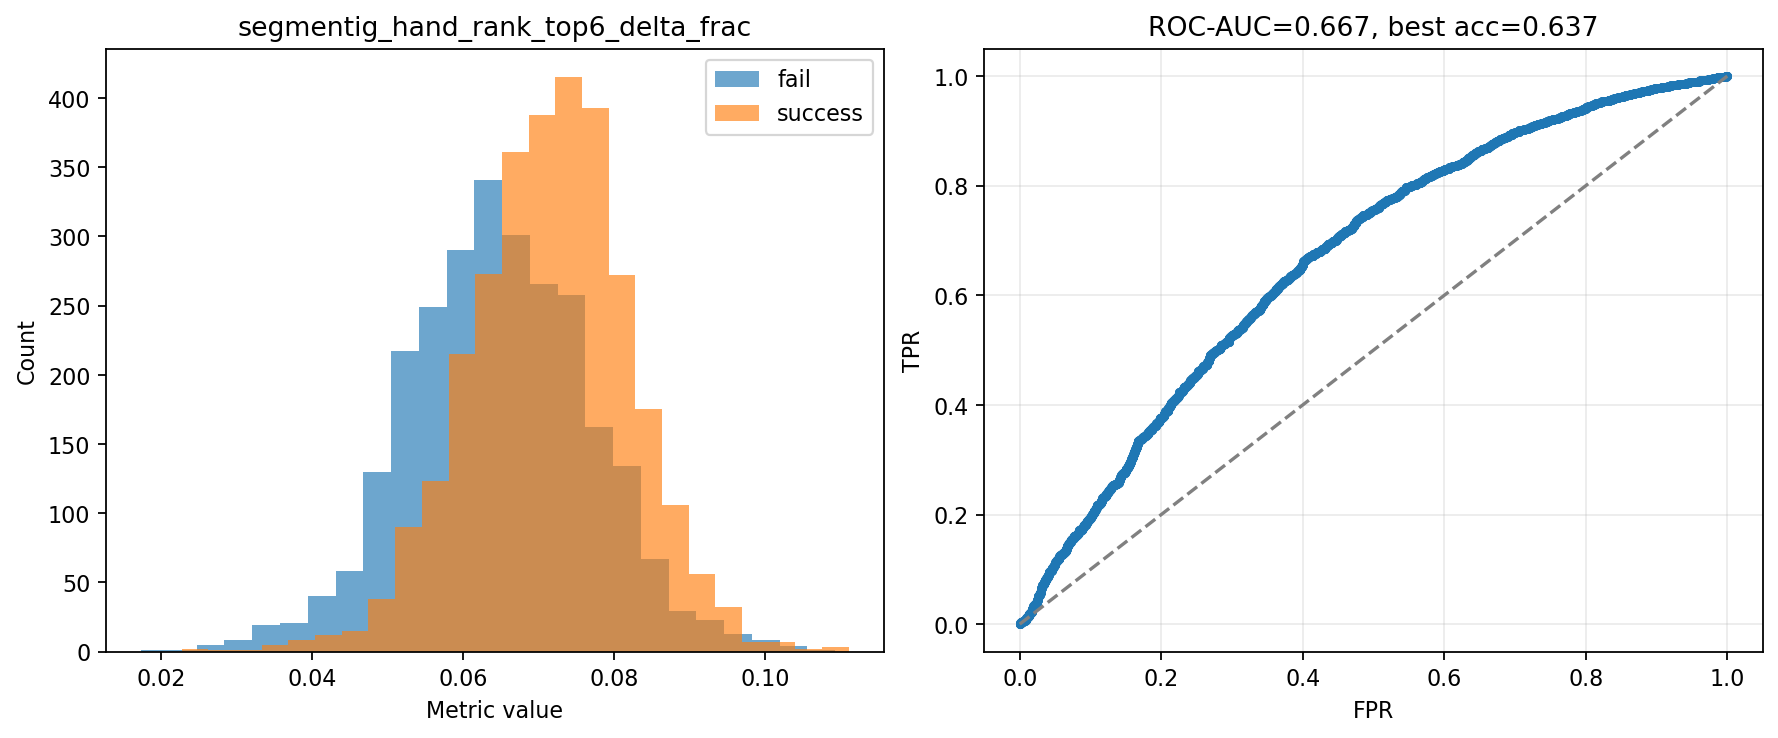

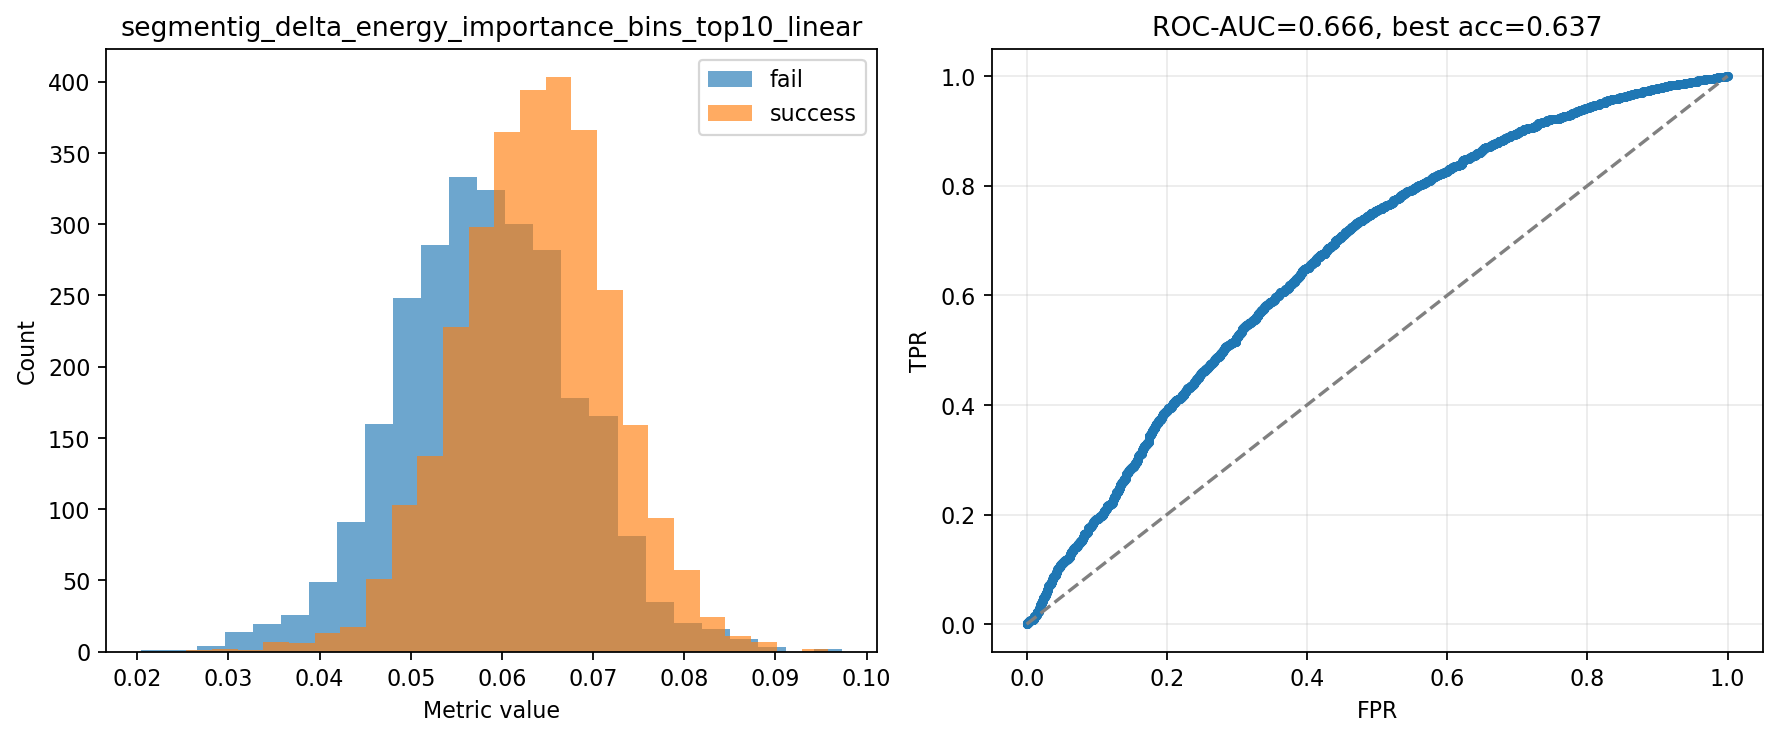

In [5]:
sf = exp.run_segmentig_success_failure_metrics(force=force_success_failure_metrics_recompute)
rows_df = select_balanced_rows(pd.DataFrame(sf['rows']), per_class=analysis_examples_per_class)
quality_df = pd.DataFrame(sf['quality']).sort_values('roc_auc', ascending=False)

print(f"segmentig success/failure cache: {sf['cache_path']}")
print(f"loaded_from_cache={sf.get('loaded_from_cache')}")
print(f"rows={len(sf['rows'])}, skipped={len(sf.get('skipped', []))}")
print(
    f"balanced rows={len(rows_df)} "
    f"({int(rows_df['success'].sum())} success / {int((~rows_df['success'].astype(bool)).sum())} fail)"
)

display(quality_df.head(30))
display(rows_df.head())
for path in quality_df['figure_path'].head(8):
    display(Image(filename=path))

### Что означают метрики success/fail

Метрики считаются в `run_segmentig_success_failure_metrics()` и используют `Δ = F_l(x_patch) - F_l(x_clean)` вместе с картой важности `SegmentIG[0;0.1]` на выбранном слое. Основные группы: magnitude/spread метрики `delta_*`, alignment метрики `segmentig_align_*`, top-k попадание дельты в важные нейроны `segmentig_delta_energy_in_importance_top`, product/bin метрики и handcrafted spatial/patch features.

,path,success,drop,segmentig_delta_energy_in_importance_top,segmentig_delta_importance_product_unsigned,segmentig_delta_importance_product_signed,segmentig_delta_energy_importance_bins_top10_linear,segmentig_delta_energy_importance_bins_top10_reciprocal,segmentig_delta_energy_importance_bins_top10_exp
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.054436,0.001292,0.000309,0.056215,0.033012,0.037176
1,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.065115,0.000173,0.000047,0.066122,0.040127,0.045201
2,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,0.058711,0.000437,0.000064,0.060676,0.034946,0.039591
3,../datasets/COCO_people/02665_train2017_image8...,True,0.369444,0.071889,0.000656,0.000076,0.072023,0.042376,0.048260
4,../datasets/COCO_people/04480_train2017_image1...,False,0.004722,0.040829,0.000547,0.000105,0.043934,0.024754,0.027541


,metric,roc_auc,best_accuracy,best_threshold,best_direction,figure_path
0,segmentig_delta_energy_in_importance_top,0.667132,0.639568,0.056406,1,new_experiments/outputs/patch_success_analysis...
1,segmentig_delta_importance_product_unsigned,0.563249,0.550301,0.000401,1,new_experiments/outputs/patch_success_analysis...
2,segmentig_delta_importance_product_signed,0.568334,0.558803,0.000038,1,new_experiments/outputs/patch_success_analysis...
3,segmentig_delta_energy_importance_bins_top10_l...,0.666285,0.637088,0.058602,1,new_experiments/outputs/patch_success_analysis...
4,segmentig_delta_energy_importance_bins_top10_r...,0.663346,0.635494,0.034357,1,new_experiments/outputs/patch_success_analysis...
5,segmentig_delta_energy_importance_bins_top10_exp,0.664821,0.635671,0.038404,1,new_experiments/outputs/patch_success_analysis...


segmentig_delta_energy_in_importance_top


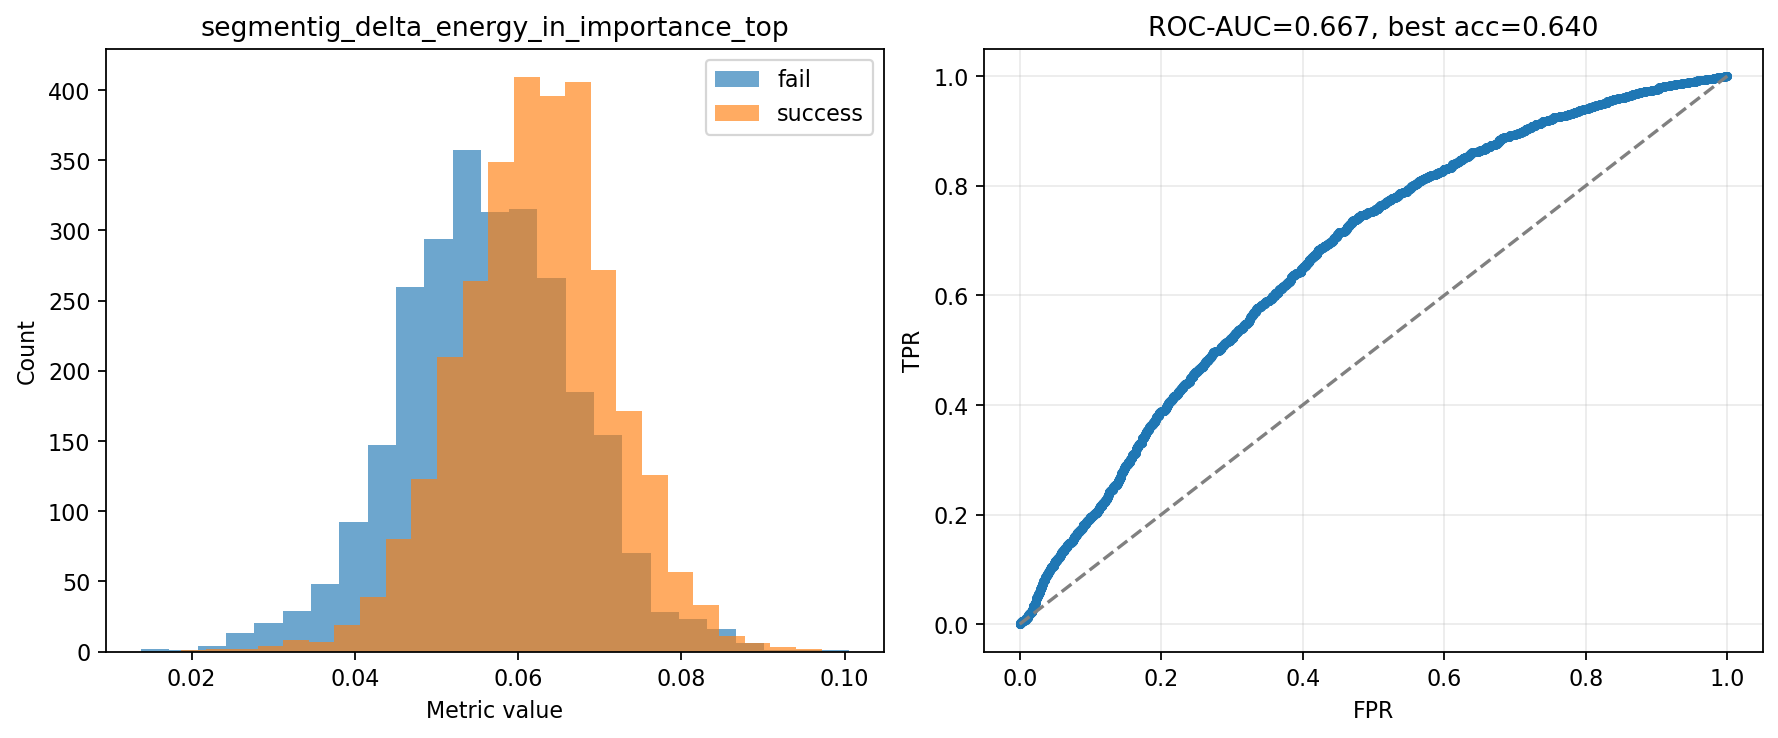

segmentig_delta_importance_product_unsigned


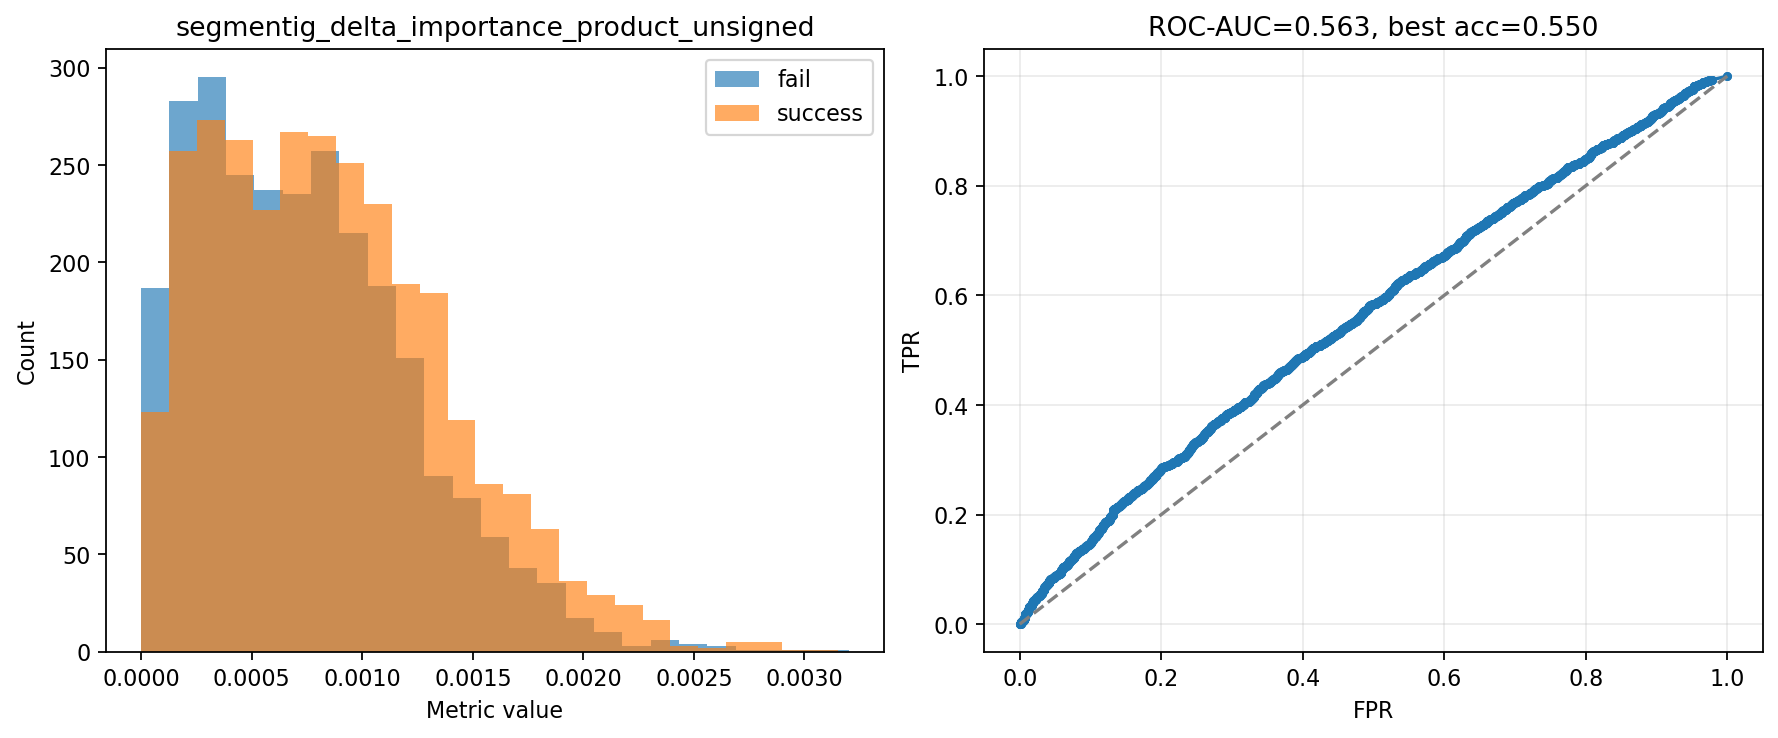

segmentig_delta_importance_product_signed


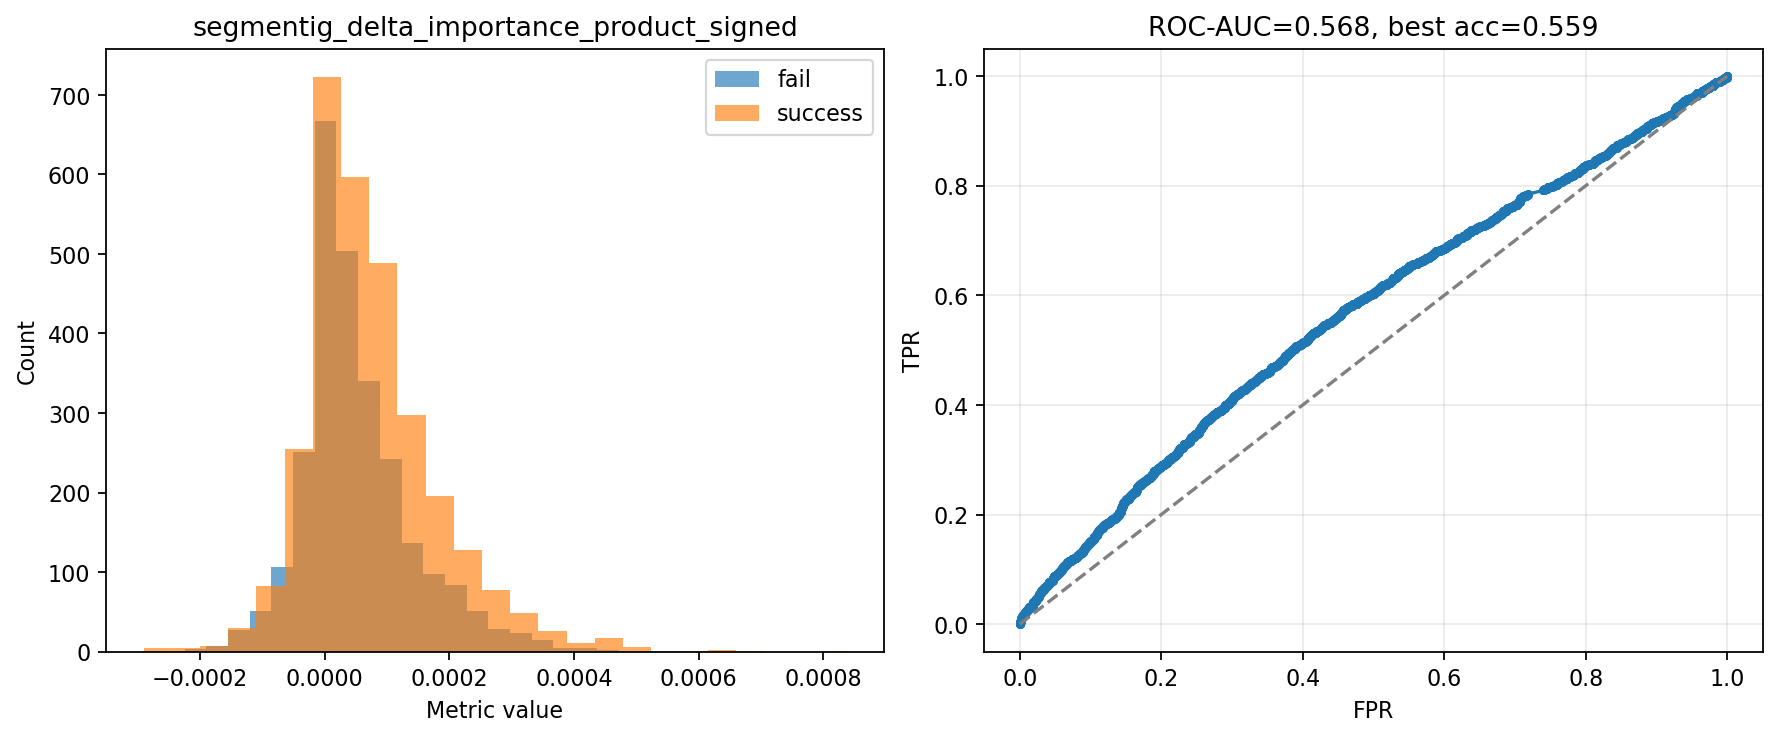

segmentig_delta_energy_importance_bins_top10_linear


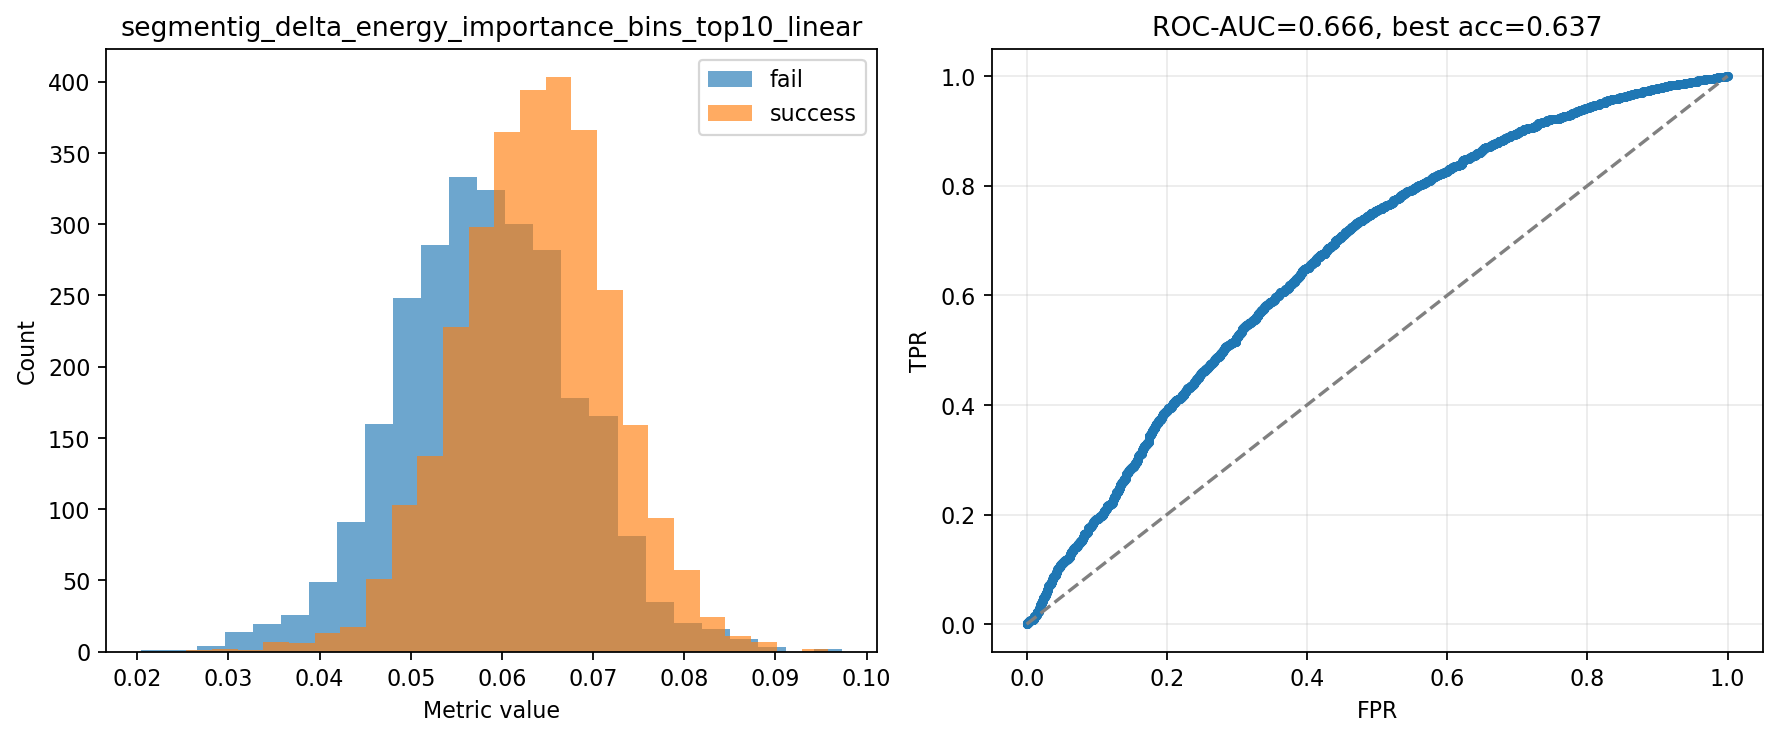

segmentig_delta_energy_importance_bins_top10_reciprocal


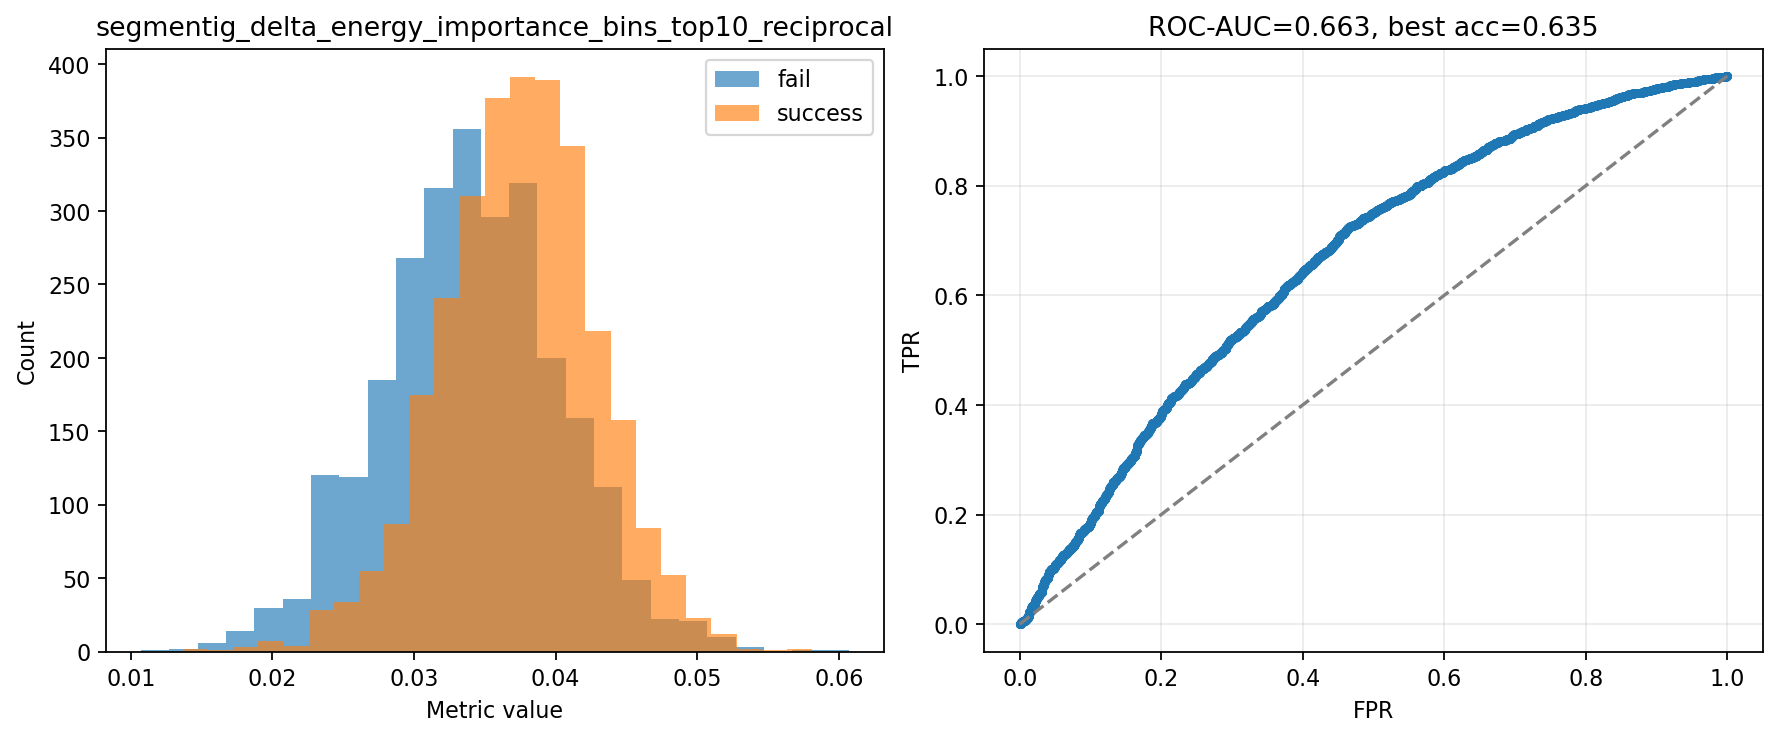

segmentig_delta_energy_importance_bins_top10_exp


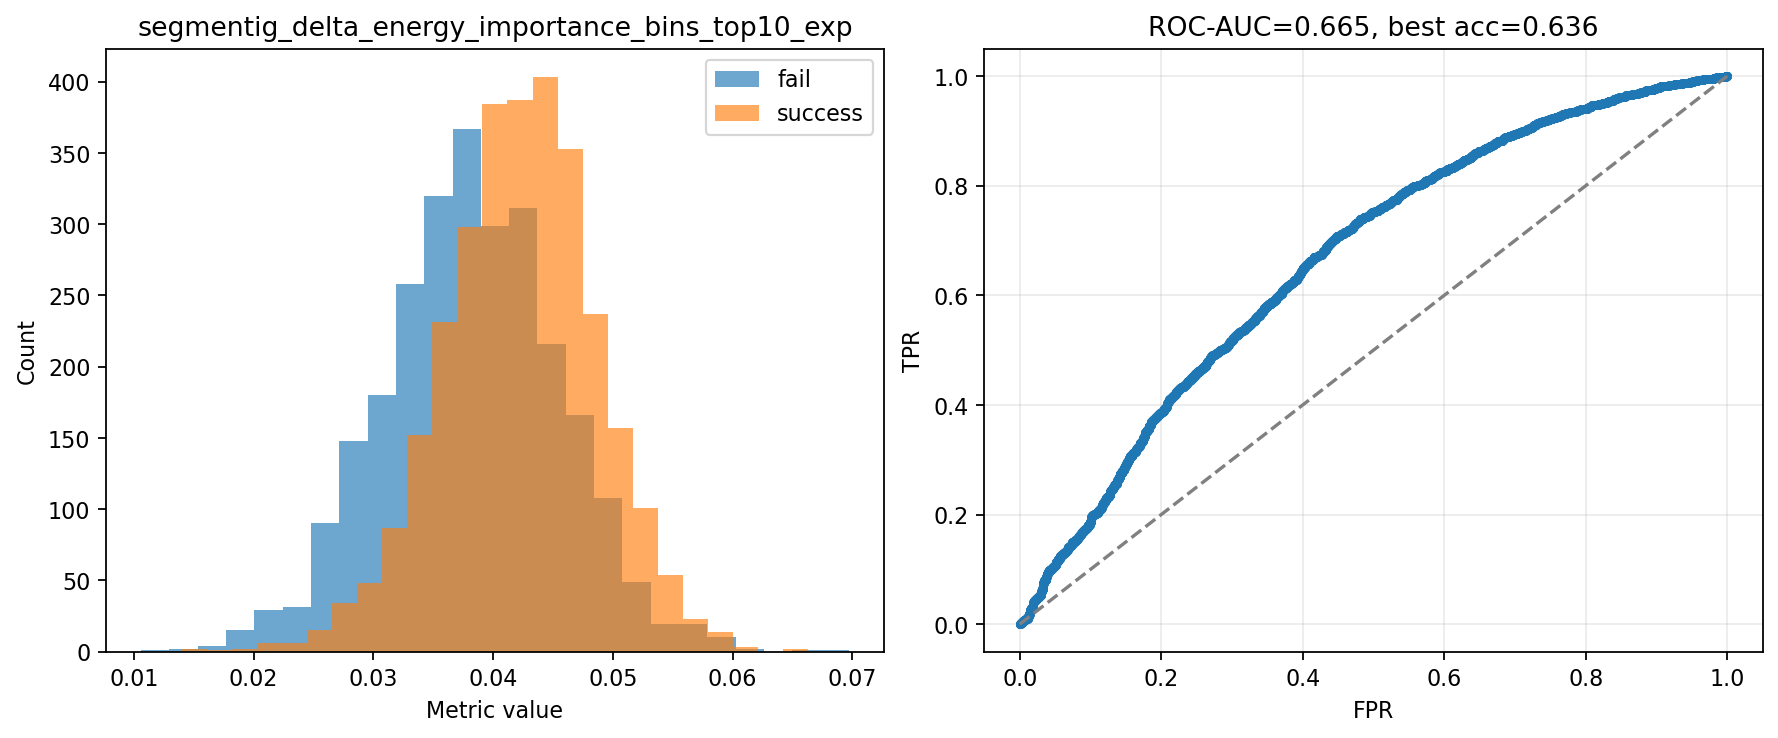

In [6]:
# SegmentIG-only metric focus.
rows_df = pd.DataFrame(sf['rows'])
quality_df = pd.DataFrame(sf['quality']).sort_values('roc_auc', ascending=False)

focus_metrics = [
    'segmentig_delta_energy_in_importance_top',
    'segmentig_delta_importance_product_unsigned',
    'segmentig_delta_importance_product_signed',
    'segmentig_delta_energy_importance_bins_top10_linear',
    'segmentig_delta_energy_importance_bins_top10_reciprocal',
    'segmentig_delta_energy_importance_bins_top10_exp',
]
available_metrics = [m for m in focus_metrics if m in rows_df.columns and m in set(quality_df['metric'])]
if not available_metrics:
    raise RuntimeError('Нет SegmentIG focus metrics в sf. Перезапусти SegmentIG-only success/failure ячейку.')

display(rows_df[['path', 'success', 'drop'] + available_metrics].head())
focus_quality = quality_df[quality_df['metric'].isin(available_metrics)].set_index('metric').loc[available_metrics].reset_index()
display(focus_quality)
for _, row in focus_quality.iterrows():
    print(row['metric'])
    display(Image(filename=row['figure_path']))

### Диагностика причины неуспеха атаки

Диагностика строится из уже сохраненных SegmentIG layer maps без повторного прохода модели, если layer-map cache готов. По строкам сравниваются success и fail. Колонки показывают среднюю энергию `|Δ|`, signed mean `Δ`, энергию `|Δ|` внутри top-важных по SegmentIG нейронов, среднюю карту важности SegmentIG и энергию `|Δ|` вне top-важных нейронов.

,drop,delta_l2_rms,topk_energy_frac,layer_maps_loaded_from_cache,segmentig_align_cosine,segmentig_align_top_jaccard,segmentig_importance_energy_in_delta_top,segmentig_delta_energy_in_importance_top
success,,,,,,,,
False,0.117636,0.463925,0.108328,1.0,0.054099,0.037652,0.126836,0.056256
True,0.711765,0.482682,0.104805,1.0,0.063801,0.044264,0.149385,0.062336


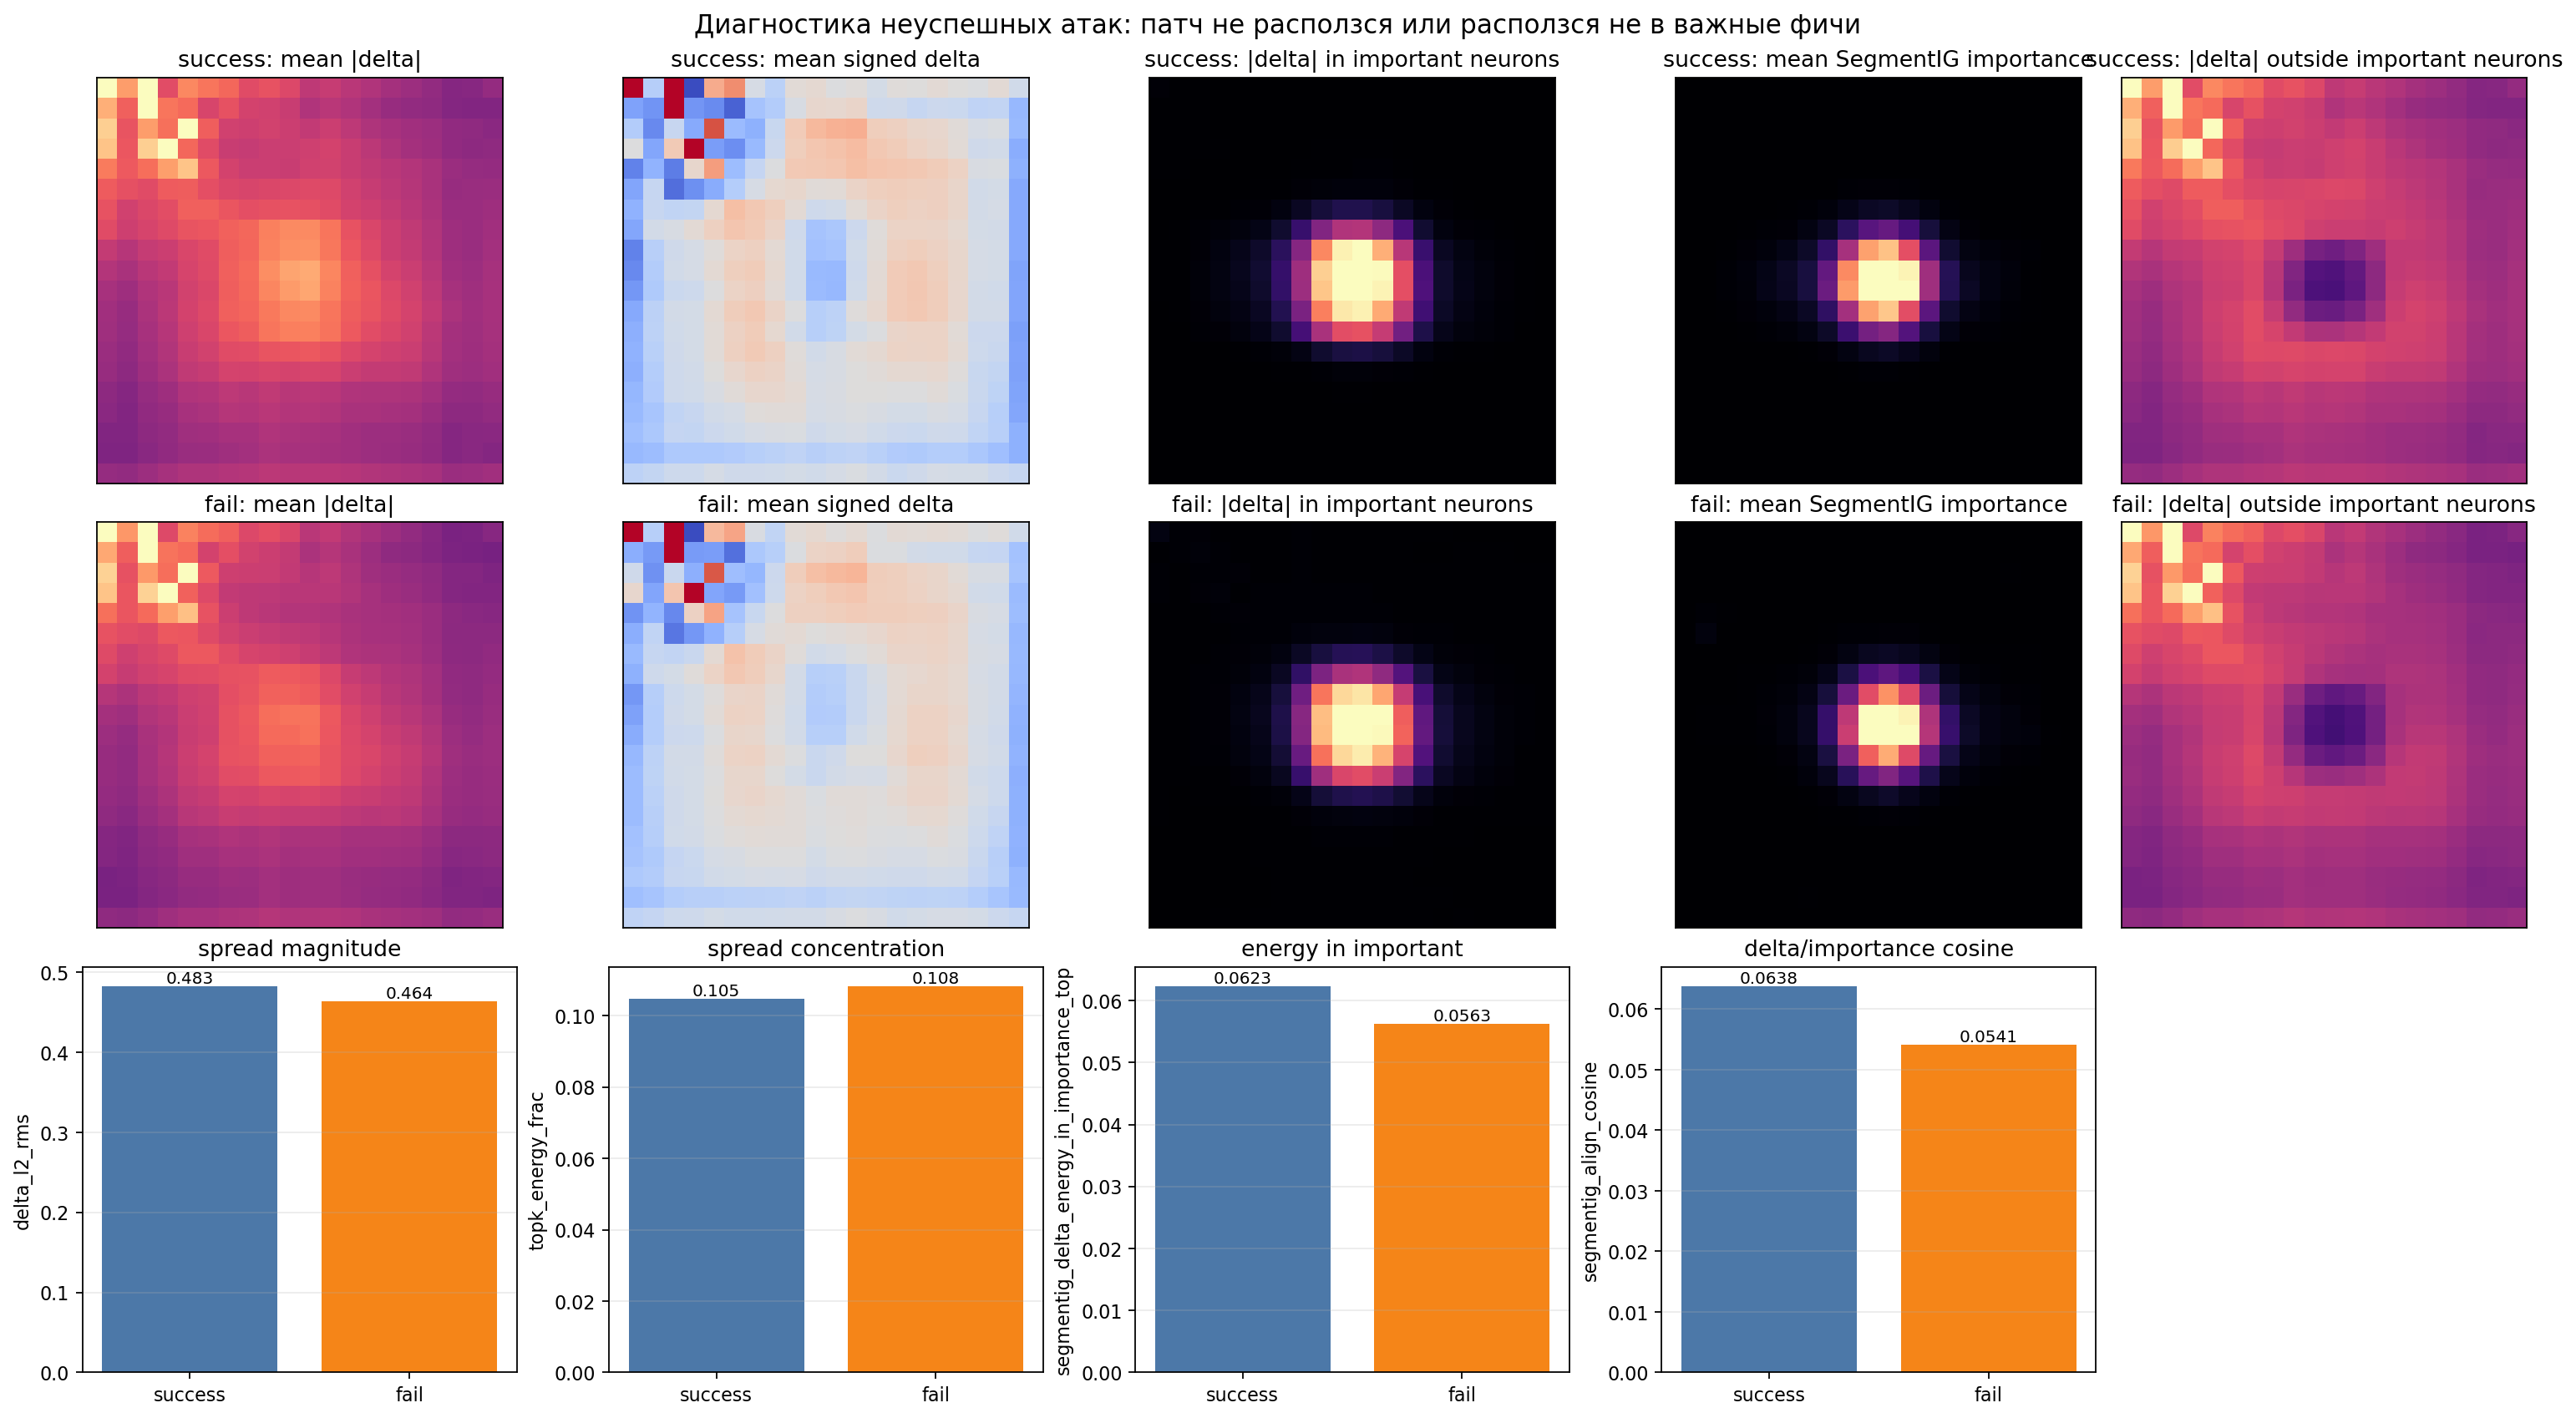

failure diagnosis cache: new_experiments/outputs/patch_success_analysis/cache/cached_failure_diagnosis_v1_bda78f81ebe6e987.pkl
loaded_from_cache=True
diagnosis rows=2650 success / 2646 fail, skipped=4


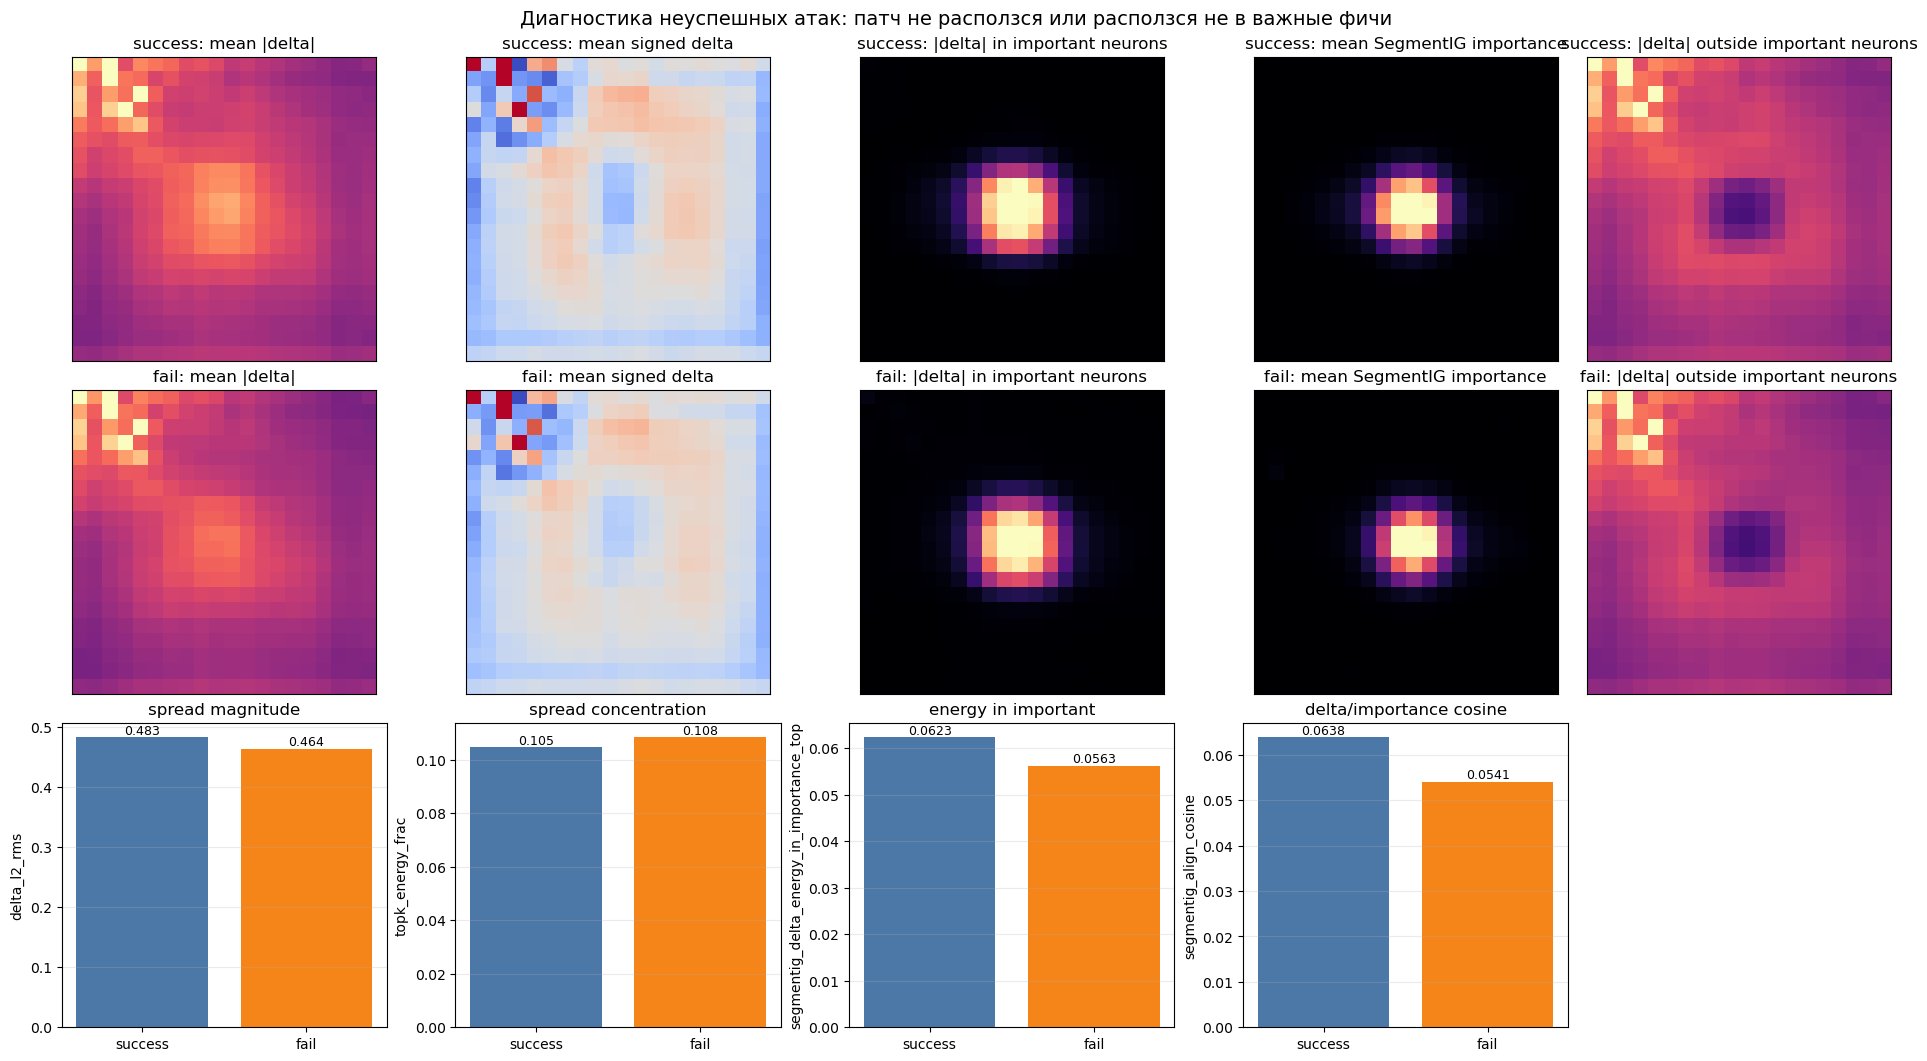

: 

In [ ]:
from patch_success_analysis import channel_metrics

selected_for_diagnosis = cache.successes[:selected_per_class] + cache.failures[:selected_per_class]
failure_diagnosis_result = channel_metrics.compute_or_load_cached_failure_diagnosis(
    exp,
    selected_for_diagnosis,
    layer_name=config.target_layer,
    top_percent=5.0,
    force=False,
)
failure_diagnosis = failure_diagnosis_result['diagnosis']
display(pd.DataFrame(failure_diagnosis['rows']).groupby('success').mean(numeric_only=True))
display(Image(filename=failure_diagnosis['figure_path']))
print(f"failure diagnosis cache: {failure_diagnosis_result['cache_path']}")
print(f"loaded_from_cache={failure_diagnosis_result['loaded_from_cache']}")
print(
    f"diagnosis rows={failure_diagnosis.get('n_success')} success / "
    f"{failure_diagnosis.get('n_fail')} fail, skipped={failure_diagnosis.get('n_skipped')}"
)